IMPORT LIBRARIES

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


LOAD DATASET

In [14]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Class labels (10 categories)
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot'
]

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Image shape      : {X_train.shape[1:]}  (height x width)")
print(f"Pixel value range: {X_train.min()} – {X_train.max()}")

Training samples : 60000
Test samples     : 10000
Image shape      : (28, 28)  (height x width)
Pixel value range: 0 – 255


NORMALIZE DATA

In [15]:

# Pixel values range from 0 to 255.
# We divide by 255.0 to scale them to the range [0, 1].

X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(f"\nAfter normalization — pixel range: {X_train.min():.1f} – {X_train.max():.1f}")


After normalization — pixel range: 0.0 – 1.0


Printing the first Training instance

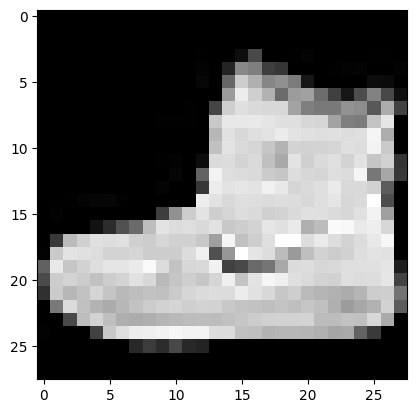

Label: 9 (Ankle boot)


In [16]:
plt.imshow(X_train[0], cmap='gray')
plt.show()
print(f"Label: {y_train[0]} ({class_names[y_train[0]]})")

RESHAPE DATA FOR CNN

In [17]:
# Fashion MNIST images are grayscale, so channels = 1.
# We add a channel dimension to satisfy this requirement.

X_train = X_train.reshape(-1, 28, 28, 1)   # shape: (60000, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)    # shape: (10000, 28, 28, 1)

print(f"\nReshaped training data : {X_train.shape}")
print(f"Reshaped test data     : {X_test.shape}")


Reshaped training data : (60000, 28, 28, 1)
Reshaped test data     : (10000, 28, 28, 1)


BUILD THE CNN MODEL

In [18]:


model = models.Sequential([

    # Convolutional Block 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu',
                  input_shape=(28, 28, 1), name='conv1'),

    # MaxPooling
    layers.MaxPooling2D(pool_size=(2, 2), name='pool1'),

    # Convolutional Block 2
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', name='conv2'),

    # Spatial dimensions halved again
    layers.MaxPooling2D(pool_size=(2, 2), name='pool2'),

      # Convolutional Block 3
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', name='conv3'),


    # Flatten
    layers.Flatten(name='flatten'),

    # Fully Connected Layer
    layers.Dense(128, activation='relu', name='dense1'),

    # Dropout to reduce overfitting
    layers.Dropout(0.5, name='dropout'),

    # Output Layer
    layers.Dense(10, activation='softmax', name='output')
])

# Print a summary of every layer, its output shape, and parameter count
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

COMPILE THE MODEL

In [19]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics=['accuracy']
)

print("\nModel compiled successfully.")


Model compiled successfully.


In [20]:
EPOCHS     = 15
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

print("\nTraining complete.")

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.7576 - loss: 0.6680 - val_accuracy: 0.8440 - val_loss: 0.4100
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.8523 - loss: 0.4158 - val_accuracy: 0.8723 - val_loss: 0.3447
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.8734 - loss: 0.3510 - val_accuracy: 0.8885 - val_loss: 0.2973
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - accuracy: 0.8869 - loss: 0.3149 - val_accuracy: 0.8872 - val_loss: 0.2921
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.8971 - loss: 0.2889 - val_accuracy: 0.8965 - val_loss: 0.2841
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - accuracy: 0.9045 - loss: 0.2662 - val_accuracy: 0.8977 - val_loss: 0.2772
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 85s 58ms/step - accuracy: 0.9093 - loss: 0.2523 - val_accuracy: 0.9082 - val_loss: 0.2516
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9151 - loss: 0.2361 - 

EVALUATE THE MODEL

In [23]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)


print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")


# Per-class accuracy
y_pred        = np.argmax(model.predict(X_test), axis=1)
correct_mask  = y_pred == y_test


for i, name in enumerate(class_names):
    mask     = y_test == i
    cls_acc  = correct_mask[mask].mean()
    print(f"  {name:<15}: {cls_acc * 100:.1f}%")


  Test Loss     : 0.2708
  Test Accuracy : 91.42%
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
  T-shirt/top    : 85.0%
  Trouser        : 97.8%
  Pullover       : 83.3%
  Dress          : 93.4%
  Coat           : 89.6%
  Sandal         : 97.9%
  Shirt          : 76.7%
  Sneaker        : 97.7%
  Bag            : 97.4%
  Ankle boot     : 95.4%


PLOT TRAINING CURVES

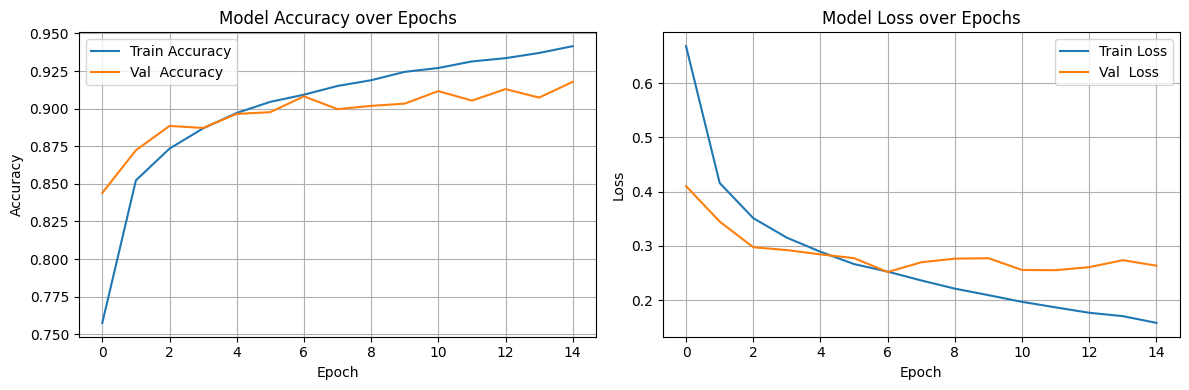


Training curves saved to 'training_curves.png'


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val  Accuracy')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val  Loss')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("\nTraining curves saved to 'training_curves.png'")